# Zadanie 1. Cena laptopów

Baza danych `laptop.csv` zawiera dane na temat cen laptopów. Zmienna `Price` oznacza cenę laptopa. Celem zadania jest zbudowanie modelu do przewidywania ceny. Zbudować model gradient boosting (GradientBoostingRegressor).

Plik `laptop_test.csv` nie zawiera kolumny `Price`. Zbudowany model należy uruchomić na danych z tego pliku, a wynik zapisać w pliku o nazwie `l.csv`. Predykcje modelu zapisać w kolumnach o nazwie `Price`.



*Kryterium oceny – RSME*

## Import bibliotek

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

## Wczytanie danych

In [424]:
df = pd.read_csv('laptop.csv')
df_test = pd.read_csv('laptop_test.csv')
print('Zbiór treningowy:', df.shape)
print('Zbiór testowy:   ', df_test.shape)

Zbiór treningowy: (773, 19)
Zbiór testowy:    (50, 18)


In [425]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,DELL,Intel,Core i3,11th,4 GB,DDR4,256 GB,1024 GB,Windows,64-bit,0 GB,ThinNlight,1 year,No,Yes,43590,3 stars,0,0
1,ASUS,AMD,Ryzen 5,Not Available,4 GB,DDR4,512 GB,0 GB,Windows,64-bit,0 GB,ThinNlight,1 year,No,Yes,49990,4 stars,14,2
2,HP,AMD,Ryzen 5,Not Available,8 GB,DDR4,512 GB,0 GB,Windows,64-bit,0 GB,ThinNlight,1 year,No,Yes,48990,4 stars,45,5
3,ASUS,Intel,Core i5,11th,8 GB,LPDDR4X,512 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,Yes,No,99990,3 stars,0,0
4,MSI,Intel,Core i7,12th,16 GB,DDR4,1024 GB,0 GB,Windows,64-bit,6 GB,Casual,No warranty,No,No,139990,4 stars,4,2


## Eksploracja danych

In [426]:
df.shape

(773, 19)

In [427]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   brand              773 non-null    str  
 1   processor_brand    773 non-null    str  
 2   processor_name     773 non-null    str  
 3   processor_gnrtn    773 non-null    str  
 4   ram_gb             773 non-null    str  
 5   ram_type           773 non-null    str  
 6   ssd                773 non-null    str  
 7   hdd                773 non-null    str  
 8   os                 773 non-null    str  
 9   os_bit             773 non-null    str  
 10  graphic_card_gb    773 non-null    str  
 11  weight             773 non-null    str  
 12  warranty           773 non-null    str  
 13  Touchscreen        773 non-null    str  
 14  msoffice           773 non-null    str  
 15  Price              773 non-null    int64
 16  rating             773 non-null    str  
 17  Number of Ratings  773 non-

In [428]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   brand              50 non-null     str  
 1   processor_brand    50 non-null     str  
 2   processor_name     50 non-null     str  
 3   processor_gnrtn    50 non-null     str  
 4   ram_gb             50 non-null     str  
 5   ram_type           50 non-null     str  
 6   ssd                50 non-null     str  
 7   hdd                50 non-null     str  
 8   os                 50 non-null     str  
 9   os_bit             50 non-null     str  
 10  graphic_card_gb    50 non-null     str  
 11  weight             50 non-null     str  
 12  warranty           50 non-null     str  
 13  Touchscreen        50 non-null     str  
 14  msoffice           50 non-null     str  
 15  rating             50 non-null     str  
 16  Number of Ratings  50 non-null     int64
 17  Number of Reviews  50 non-nul

In [429]:
df.duplicated().sum()

np.int64(20)

In [430]:
dupes = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
print(dupes.shape)
dupes.head(20)

(35, 19)


,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
14,APPLE,M1,M1,10th,16 GB,DDR4,1024 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,225990,4 stars,42,8
522,APPLE,M1,M1,10th,16 GB,DDR4,1024 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,225990,4 stars,42,8
367,APPLE,M1,M1,10th,16 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,45,4
758,APPLE,M1,M1,10th,16 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,45,4
386,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,85990,4 stars,6725,629
616,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,85990,4 stars,6725,629
129,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,112990,4 stars,640,70
402,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,112990,4 stars,640,70
563,APPLE,M1,M1,10th,8 GB,DDR4,512 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,6725,629
678,APPLE,M1,M1,10th,8 GB,DDR4,512 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,6725,629


In [431]:
dupes.shape[0] / df.shape[0] * 100

4.527813712807244

Duplikaty to tylko 4% danych, więc usuwanie ich pewnie nic nie zmieni, jednak zrobię to w celach edukacyjnych.

In [432]:
df_dropped = df.drop_duplicates().reset_index(drop=True)
print('Przed:', len(df), ', Po:', len(df_dropped))

Przed: 773 , Po: 753


In [433]:
print('Pozostałe duplikaty:', df_dropped.duplicated().sum())

Pozostałe duplikaty: 0


In [434]:
# Przegląd zmiennych kategorycznych
cat_cols = ['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
            'ram_type', 'os', 'weight', 'warranty', 'Touchscreen', 'msoffice', 'rating']
for col in cat_cols:
    print(f'{col}: {df_dropped[col].nunique()} unikalnych wartości: {df_dropped[col].unique()[:8]}')

brand: 8 unikalnych wartości: <StringArray>
['DELL', 'ASUS', 'HP', 'MSI', 'acer', 'Avita', 'APPLE', 'Lenovo']
Length: 8, dtype: str
processor_brand: 3 unikalnych wartości: <StringArray>
['Intel', 'AMD', 'M1']
Length: 3, dtype: str
processor_name: 11 unikalnych wartości: <StringArray>
['Core i3', 'Ryzen 5', 'Core i5', 'Core i7', 'Ryzen 7',      'M1', 'Ryzen 3',
 'Ryzen 9']
Length: 8, dtype: str
processor_gnrtn: 8 unikalnych wartości: <StringArray>
['11th', 'Not Available', '12th', '8th', '10th', '7th', '9th', '4th']
Length: 8, dtype: str
ram_type: 6 unikalnych wartości: <StringArray>
['DDR4', 'LPDDR4X', 'LPDDR4', 'LPDDR3', 'DDR3', 'DDR5']
Length: 6, dtype: str
os: 3 unikalnych wartości: <StringArray>
['Windows', 'DOS', 'Mac']
Length: 3, dtype: str
weight: 3 unikalnych wartości: <StringArray>
['ThinNlight', 'Casual', 'Gaming']
Length: 3, dtype: str
warranty: 4 unikalnych wartości: <StringArray>
['1 year', 'No warranty', '2 years', '3 years']
Length: 4, dtype: str
Touchscreen: 2 unikalnyc

Dystrybucja zmiennych numerycznych:


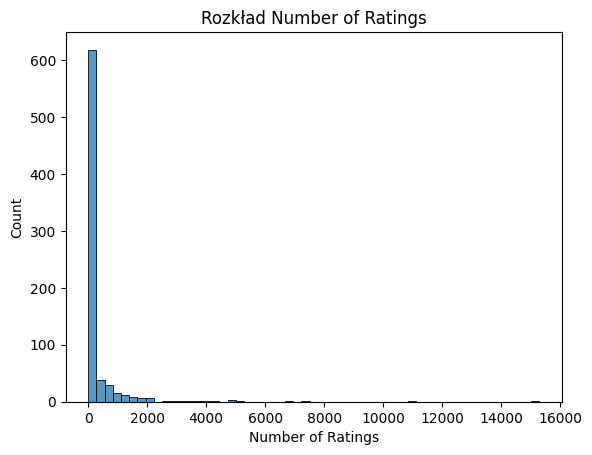

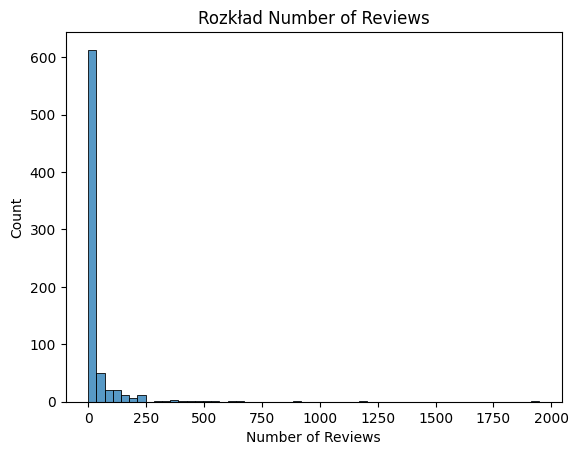

In [435]:
print('Dystrybucja zmiennych numerycznych:')
for col in df_dropped.select_dtypes(include='number').columns.drop('Price'):
    sns.histplot(data = df_dropped, x=col)
    plt.title(f'Rozkład {col}')
    plt.show()

In [436]:
heavy_tail_cols = ['Number of Ratings', 'Number of Reviews']

def iqr_count(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    count = 0
    
    for x in s:
        if x < lo or x > hi:
            count += 1
    return count

print('Outliery:')
for col in heavy_tail_cols:
    print(f'  {col}: {iqr_count(df_dropped[col])}')

Outliery:
  Number of Ratings: 121
  Number of Reviews: 121


In [437]:
df_clean = df_dropped.copy()
df_test_clean = df_test.copy()


for col in heavy_tail_cols:
    df_clean[col] = np.log1p(df_clean[col])
    df_test_clean[col] = np.log1p(df_test_clean[col])


for col in heavy_tail_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    df_test_clean[col] = df_test_clean[col].clip(lower=lo, upper=hi)

print('Outliery po transformacji')
for col in heavy_tail_cols:
    print(f'  {col}: {iqr_count(df_clean[col])}')

Outliery po transformacji
  Number of Ratings: 0
  Number of Reviews: 0


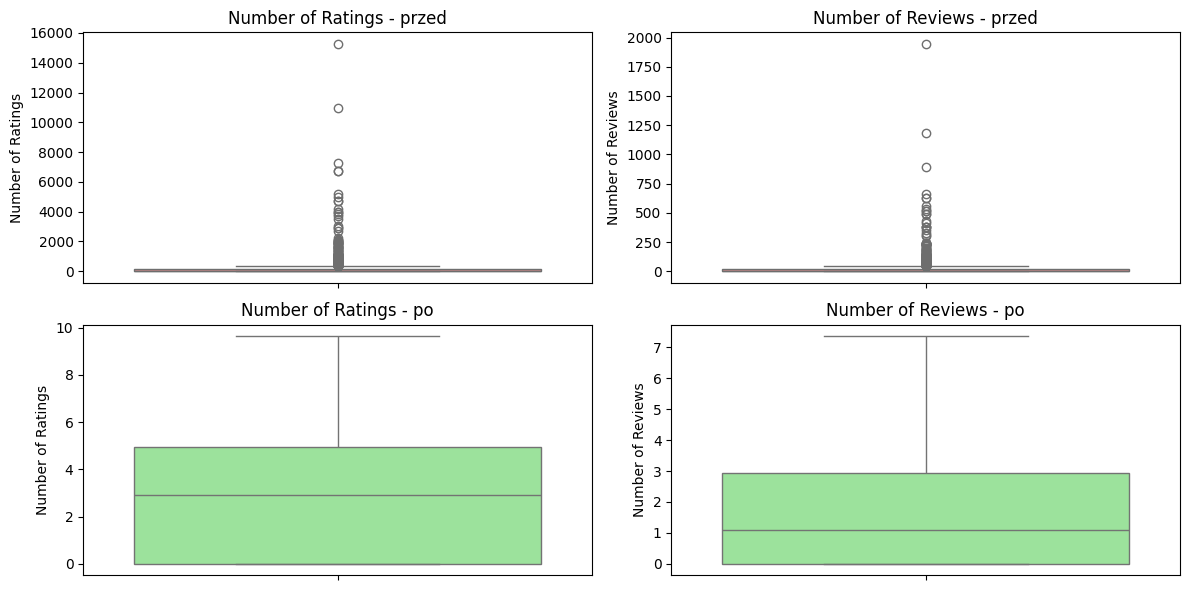

In [438]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, col in enumerate(heavy_tail_cols):
    sns.boxplot(y=df_dropped[col], ax=axes[0, i], color='lightcoral')
    axes[0, i].set_title(f'{col} - przed')
    sns.boxplot(y=df_clean[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'{col} - po')
plt.tight_layout()
plt.show()

## Przygotowanie danych

In [439]:
# Dopasowanie LabelEncoder na polaczonym zbiorze, zeby zachowac spójność kodowania
combined = pd.concat([df_clean, df_test_clean], axis=0, ignore_index=True)

cat_cols = ['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
            'ram_type', 'os', 'weight', 'warranty', 'Touchscreen', 'msoffice']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(combined[col].astype(str))
    encoders[col] = le

def preprocess(data, encoders):
    df_proc = data.copy()

    for col in ['ram_gb', 'ssd', 'hdd', 'graphic_card_gb']:
        df_proc[col] = df_proc[col].str.extract(r'(\d+)').astype(int)

    df_proc['os_bit'] = df_proc['os_bit'].str.extract(r'(\d+)').astype(int)
    df_proc['rating'] = df_proc['rating'].str.extract(r'(\d+)').astype(int)

    for col in cat_cols:
        df_proc[col] = encoders[col].transform(df_proc[col].astype(str))

    return df_proc

df_proc = preprocess(df_clean, encoders)
df_test_proc = preprocess(df_test_clean, encoders)

print('Przetworzone dane treningowe:', df_proc.shape)
print('Przetworzone dane testowe:   ', df_test_proc.shape)

Przetworzone dane treningowe: (753, 19)
Przetworzone dane testowe:    (50, 18)


In [440]:
feature_cols = []
for col in df_proc.columns:
    if col != 'Price':
        feature_cols.append(col)

X = df_proc[feature_cols]
y = df_proc['Price']
X_pred = df_test_proc[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Model GradientBoostingRegressor

### Model bazowy

In [441]:
gbr_base = GradientBoostingRegressor(random_state=42)
gbr_base.fit(X_train, y_train)
y_pred_base = gbr_base.predict(X_val)
rmse_base = mean_squared_error(y_val, y_pred_base) ** 0.5
print(f'RMSE modelu bazowego: {rmse_base:.2f}')

RMSE modelu bazowego: 20770.84


### Strojenie hiperparametrów (RandomizedSearchCV)

In [442]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 2, 3, 5]
}

gbr = GradientBoostingRegressor(random_state=42)
rand_search = RandomizedSearchCV(
    gbr, params,
    n_iter=80,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
)
rand_search.fit(X_train, y_train)

best_params = rand_search.best_params_
best_cv_rmse = (-rand_search.best_score_) ** 0.5
print('Najlepsze parametry:', best_params)
print(f'CV RMSE (treningowy): {best_cv_rmse:.2f}')

Najlepsze parametry: {'subsample': 1.0, 'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.1}
CV RMSE (treningowy): 22435.73


In [443]:
# Ocena na zbiorze walidacyjnym
best_model = rand_search.best_estimator_
y_pred_val = best_model.predict(X_val)
rmse_val = mean_squared_error(y_val, y_pred_val) ** 0.5

mean = df_proc['Price'].mean()
median = df_proc['Price'].median()
print(f'RMSE na zbiorze walidacyjnym: {rmse_val:.2f}')
print(f'Średnia cena - : {mean:.2f}')

RMSE na zbiorze walidacyjnym: 19903.18
Średnia cena - : 76832.38


### Ważność zmiennych

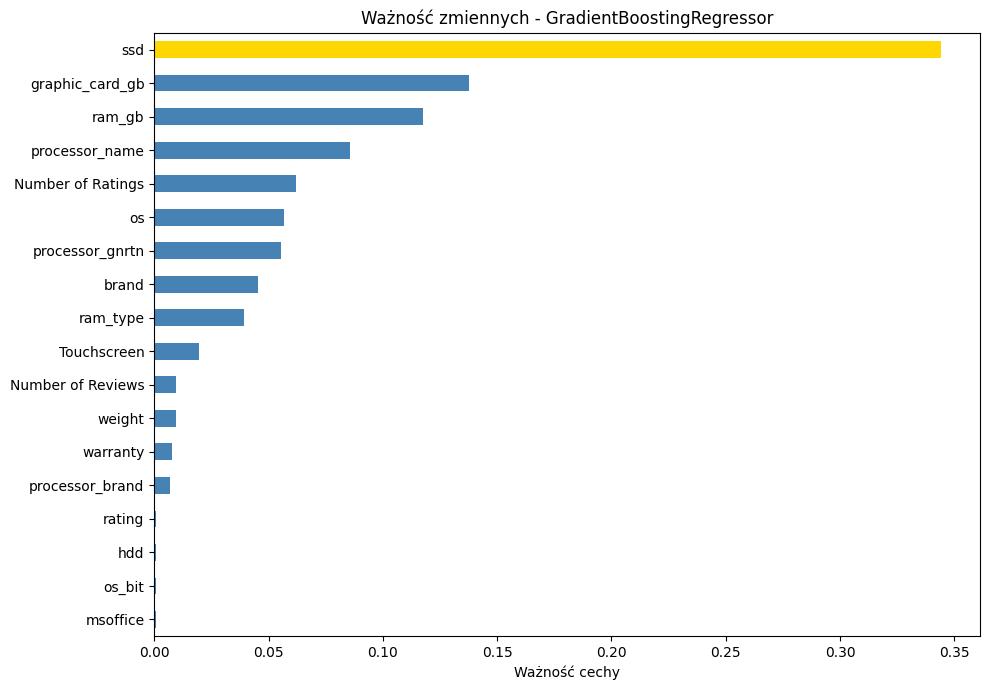

In [444]:
feature_importance = pd.Series(best_model.feature_importances_, index=feature_cols)
feature_importance = feature_importance.sort_values(ascending=True)


colors = []
for feature in feature_importance:
    if feature < feature_importance.max():
        colors.append('steelblue')
    else:
        colors.append('gold')
        

plt.figure(figsize=(10, 7))

feature_importance.plot(kind='barh', color=colors)

plt.xlabel('Ważność cechy')
plt.title('Ważność zmiennych - GradientBoostingRegressor')
plt.tight_layout()
plt.show()

## Predykcja na zbiorze testowym

In [445]:
price_pred = best_model.predict(X_pred)
print(f'Liczba predykcji: {len(price_pred)}')
print(f'Liczba rzędów w zbiorze testowym: {len(df_test)}')

Liczba predykcji: 50
Liczba rzędów w zbiorze testowym: 50


In [446]:
l_csv = pd.DataFrame({'Price': price_pred.astype(int)})
l_csv.to_csv('l.csv', index=False)